In [1]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

import pandas as pd
import numpy as np
from windrose import WindroseAxes
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C:\Users\nickp\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

start_years = [2023,2024,2025]
start_month = '11'
end_month = '02'

In [4]:
url = "https://archive-api.open-meteo.com/v1/archive"
df_daily_list = []
for year in start_years:
    params = {
        "latitude": 42.772999,
        "longitude": -78.792305,
        "start_date": str(year) + '-' + start_month + '-01',
        "end_date": str(year+1) + '-' + end_month + '-01',
        "daily": ["wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant", "wind_gusts_10m_mean", "wind_speed_10m_mean"],
        "timezone": "America/New_York",
        "wind_speed_unit": "mph",
    }
    responses = openmeteo.weather_api(url, params = params)
    response = responses[0]
    
    # Process daily data. The order of variables needs to be the same as requested.
    daily = response.Daily()
    daily_wind_speed_10m_max = daily.Variables(0).ValuesAsNumpy()
    daily_wind_gusts_10m_max = daily.Variables(1).ValuesAsNumpy()
    daily_wind_direction_10m_dominant = daily.Variables(2).ValuesAsNumpy()
    daily_wind_gusts_10m_mean = daily.Variables(3).ValuesAsNumpy()
    daily_wind_speed_10m_mean = daily.Variables(4).ValuesAsNumpy()

    daily_data = {
        "date": pd.date_range(
            start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = daily.Interval()),
            inclusive = "left"
        ).tz_convert(response.Timezone().decode())
    }

    daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
    daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
    daily_data["wind_direction_10m_dominant"] = daily_wind_direction_10m_dominant
    daily_data["wind_gusts_10m_mean"] = daily_wind_gusts_10m_mean
    daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean

    daily_dataframe = pd.DataFrame(data = daily_data)
    df_daily_list.append(daily_dataframe)

In [5]:
df_daily = pd.concat(df_daily_list, axis=0, ignore_index=True)

In [6]:
labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
df_daily['bin_idx'] = (((df_daily['wind_direction_10m_dominant'] / 22.5) + 0.5).astype(int) % 16)
df_daily['sector'] = [labels[i] for i in df_daily['bin_idx']]
df_daily

,date,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,wind_gusts_10m_mean,wind_speed_10m_mean,bin_idx,sector
0,2023-11-01 00:00:00-04:00,12.180871,25.725500,301.849884,16.889349,8.083426,13,WNW
1,2023-11-02 00:00:00-04:00,16.107952,34.226101,224.225876,20.002508,9.762729,10,SW
2,2023-11-03 00:00:00-04:00,15.844847,30.646900,202.355499,28.027744,14.425839,9,SSW
3,2023-11-04 00:00:00-04:00,14.892440,28.409899,234.339905,14.102422,6.722612,10,SW
4,2023-11-05 00:00:00-04:00,7.189789,14.316800,342.087402,9.675026,4.531920,15,NNW
...,...,...,...,...,...,...,...,...
274,2026-01-27 23:00:00-05:00,20.280659,38.028999,245.862122,27.179552,14.065111,11,WSW
275,2026-01-28 23:00:00-05:00,13.704706,27.291399,290.800049,22.994495,12.049071,13,WNW
276,2026-01-29 23:00:00-05:00,13.693748,27.515100,295.922302,19.825413,10.486125,13,WNW
277,2026-01-30 23:00:00-05:00,12.238250,23.041100,320.840210,13.161017,6.570449,14,NW


In [7]:
df_daily_filtered = df_daily[df_daily['wind_gusts_10m_mean'] > 0.5]
custom_blue_red = LinearSegmentedColormap.from_list("BlueRed", ["#0000FF", "#FF0000"]) # Blue to Red
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

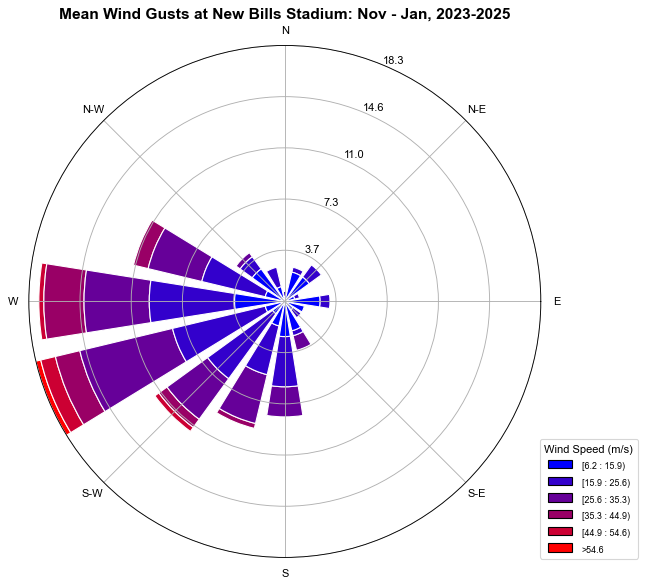

In [8]:
ax = WindroseAxes.from_ax()
ax.bar(
    df_daily_filtered['wind_direction_10m_dominant'], 
    df_daily_filtered['wind_gusts_10m_mean'], 
    normed=True, # Converts raw counts to percentages (highly recommended for multi-year data)
    opening=0.8, 
    edgecolor='white', 
    nsector=16, # Automatically handles the 16-sector binning
    cmap=custom_blue_red
)

# 4. Format legend to show percentage frequencies
ax.set_legend(
    title="Wind Speed (m/s)", 
    loc="lower left", 
    bbox_to_anchor=(1, 0),
    prop={'family': 'Arial', 'size': 11} 
)

# Ensure the title also respects the font choice
plt.title("Mean Wind Gusts at New Bills Stadium: Nov - Jan, 2023-2025", fontname="Arial", fontsize=14, weight='bold')
plt.savefig(
    'wind_rose_chart.png', 
    dpi=300,               # High resolution suitable for print and presentations
    bbox_inches='tight',   # Prevents the legend or titles from being cut off
    transparent=False      # Saves with a solid white background instead of clear
)
plt.show()